# Checking the data

In [1]:
##Import the required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn import metrics


In [2]:
## reading the data 
df = pd.read_csv('Shampoo_sales.csv')

In [3]:
df.shape

(36, 2)

In [4]:
df.tail()

,Month,Sales
31,3-08,407.6
32,3-09,682.0
33,3-10,475.3
34,3-11,581.3
35,3-12,646.9


<font size="3">__This dataset describes the monthly number of sales of shampoo over a 3 year period. The units are a sales count and there are 36 observations.__</font>


In [5]:
date = pd.date_range(start='1/1/2001', end='12/31/2003', freq='M')

In [6]:
df['Time_Stamp'] = pd.DataFrame(date,columns=['Date'])


In [7]:
df = df.set_index('Time_Stamp')
df.head()

,Month,Sales
Time_Stamp,,
2001-01-31,1-01,266.0
2001-02-28,1-02,145.9
2001-03-31,1-03,183.1
2001-04-30,1-04,119.3
2001-05-31,1-05,180.3


In [8]:
df_final = df.drop(['Month'], axis=1)

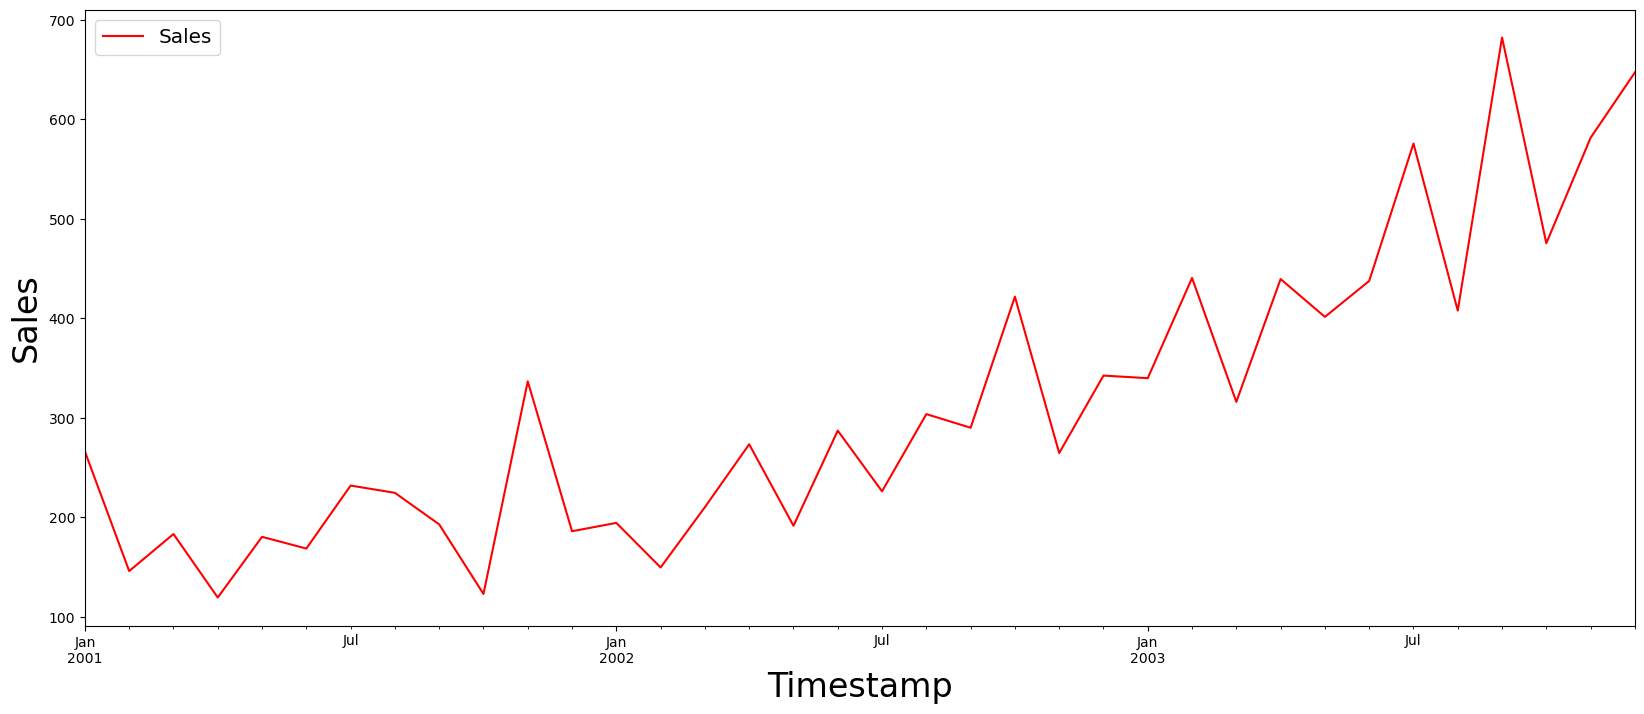

In [9]:
#Plotting the time-series
df_final.plot(figsize=(20,8),color='red')
plt.xlabel('Timestamp',fontsize=24)
plt.ylabel('Sales',fontsize=24)
plt.rc('xtick',labelsize=18)
plt.rc('ytick',labelsize=18)
plt.legend(fontsize="x-large")

<font size="3">__we deduced that the sales increase in the fall compared to other seasons.__</font>
 

## Split our data

In [10]:
## split our data to 70:30 training and test data
train    =   df_final[0:int(len(df)*0.7)] 
test     =   df_final[int(len(df)*0.7):]

# Applying the regression

In [11]:
# get the number of each month of the 3 years of the test and training data
train_time = [i+1 for i in range(len(train))]
test_time = [i+26 for i in range(len(test))]
# get a copy of the training and test data in order to use in regression
LinearRegression_train = train.copy()
LinearRegression_test = test.copy()
# add the number of month to the regression dataframe
LinearRegression_train['time'] = train_time
LinearRegression_test['time'] = test_time

print('First  rows of Training Data','\n',LinearRegression_train.head(),'\n')


First  rows of Training Data 
             Sales  time
Time_Stamp             
2001-01-31  266.0     1
2001-02-28  145.9     2
2001-03-31  183.1     3
2001-04-30  119.3     4
2001-05-31  180.3     5 



In [12]:
lr = LinearRegression()
lr.fit(LinearRegression_train[['time']],LinearRegression_train['Sales'].values)

LinearRegression()

In [13]:
# apply regression between months and sales
train_predictions_model1 = lr.predict(LinearRegression_train[['time']])
LinearRegression_train['RegOnTime'] = train_predictions_model1

test_predictions_model1 = lr.predict(LinearRegression_test[['time']])
LinearRegression_test['RegOnTime'] = test_predictions_model1

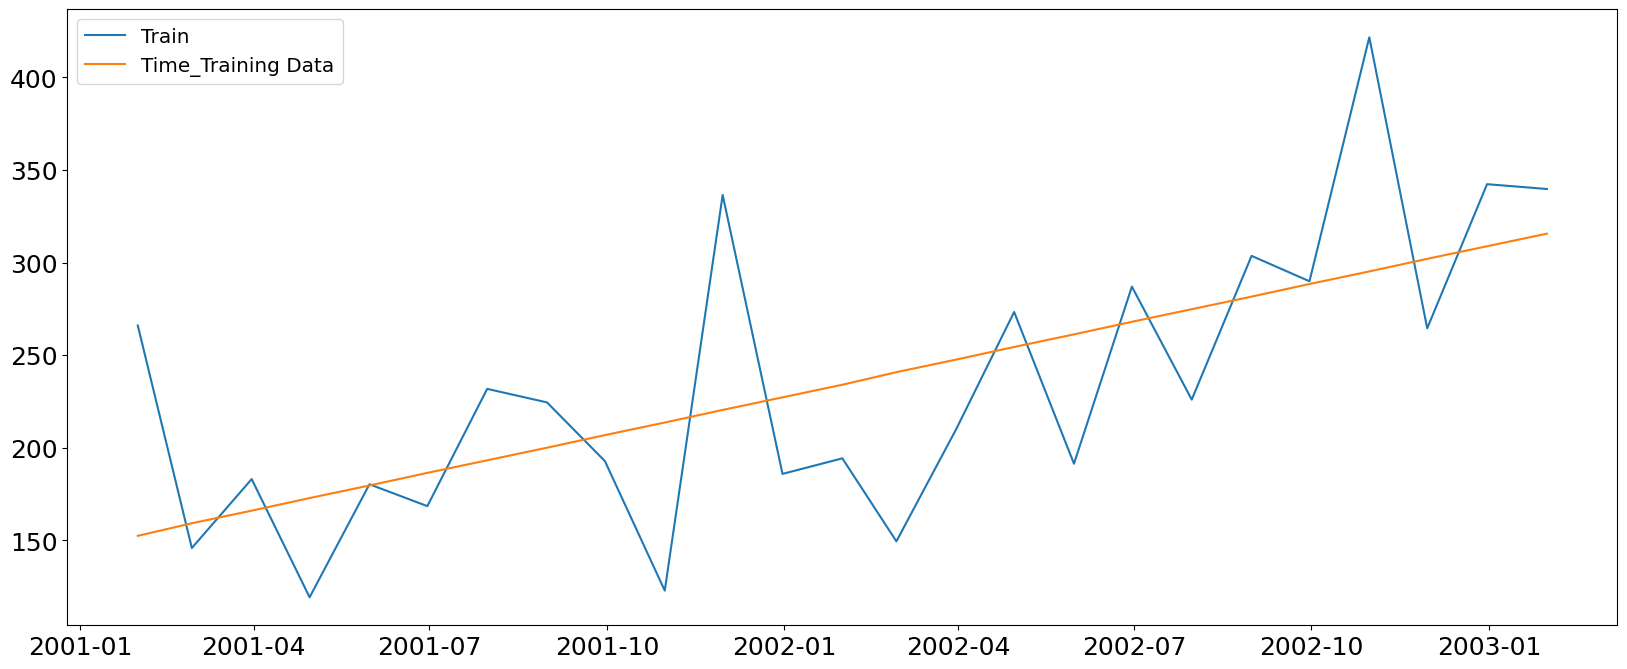

In [14]:
#Plotting the regression of data
plt.figure(figsize=(20,8))
plt.plot( train['Sales'], label='Train')
plt.plot(LinearRegression_train['RegOnTime'], label='Time_Training Data')
plt.legend(loc=10)
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['axes.titlesize'] = 18
plt.legend(fontsize="x-large")

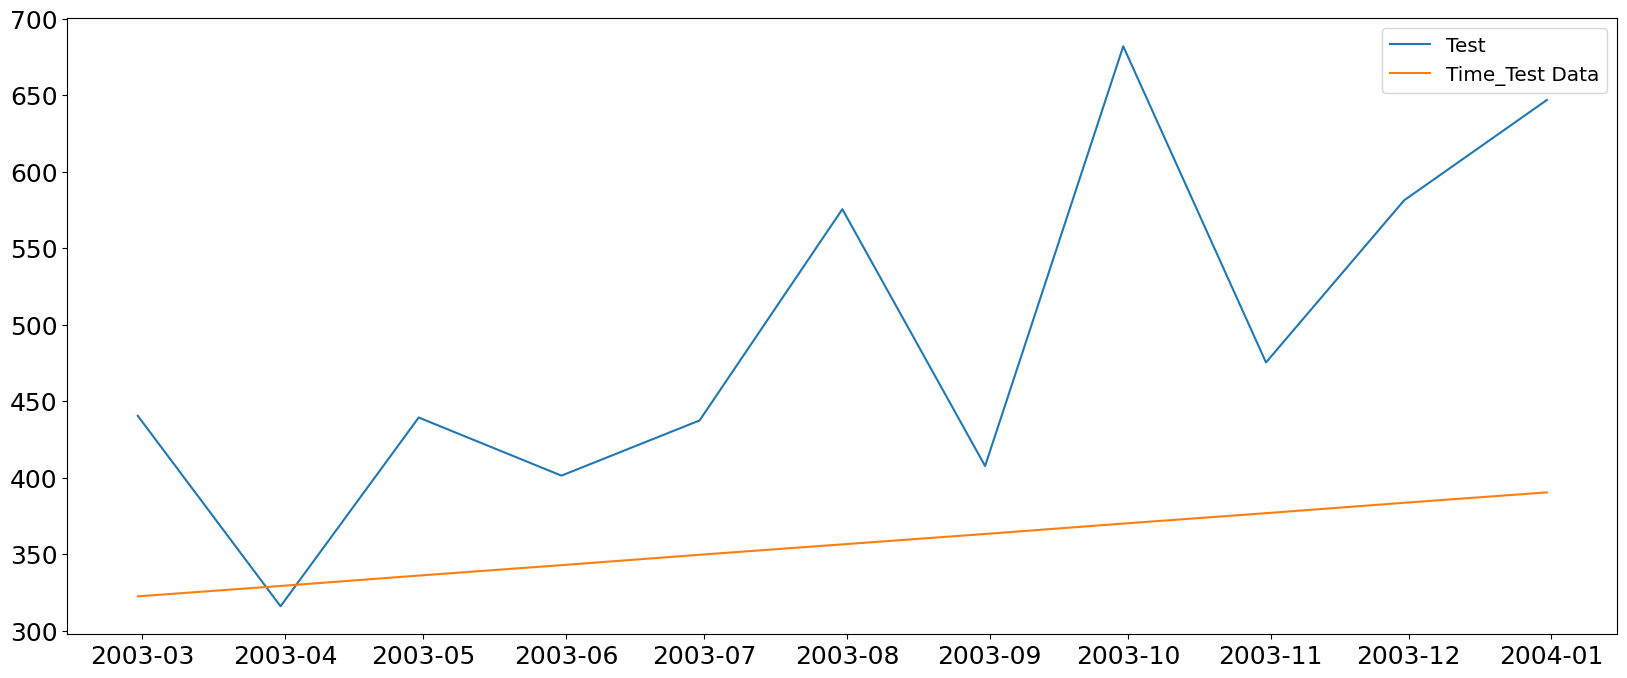

In [15]:
plt.figure(figsize=(20,8))
plt.plot(test['Sales'], label='Test')
plt.plot(LinearRegression_test['RegOnTime'], label='Time_Test Data')
plt.legend(loc='best')
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 16
plt.legend(fontsize="x-large")

<font size="3">__After we plotting our regression models we found that our model is poor as it can't predict the test data well__</font>
 

## Evalution using MSE

In [16]:
rmse_model1_train = metrics.mean_squared_error(train['Sales'],train_predictions_model1,squared=False)
print("MSE on the training data %3.3f " %(rmse_model1_train))
rmse_model1_test = metrics.mean_squared_error(test['Sales'],test_predictions_model1,squared=False)
print("MSE on the test data %3.3f " %(rmse_model1_test))


MSE on the training data 56.962 
MSE on the test data 164.563 
